# Import libriaries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Mount the drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Load and check the gallstone file

In [ ]:
file_path_in_drive = '/content/drive/My Drive/CIS 315 Data/gallstone.csv'

try:
    df = pd.read_csv(file_path_in_drive)
    print(f"Successfully loaded '{file_path_in_drive}'. Here are the first 5 rows:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path_in_drive}' was not found. Please ensure the path is correct and Google Drive is mounted.")
    print("You can check the file path by navigating your Google Drive in the left file browser pane after mounting.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully loaded '/content/drive/My Drive/CIS 315 Data/gallstone.csv'. Here are the first 5 rows:


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


# Explore the gallstone data



In [ ]:
print("DataFrame Shape:", df.shape)
print("\nDataFrame Columns:", df.columns)
print("\nDataFrame Info:")
df.info()

DataFrame Shape: (319, 39)

DataFrame Columns: Index(['Gallstone Status', 'Age', 'Gender', 'Comorbidity',
       'Coronary Artery Disease (CAD)', 'Hypothyroidism', 'Hyperlipidemia',
       'Diabetes Mellitus (DM)', 'Height', 'Weight', 'Body Mass Index (BMI)',
       'Total Body Water (TBW)', 'Extracellular Water (ECW)',
       'Intracellular Water (ICW)',
       'Extracellular Fluid/Total Body Water (ECF/TBW)',
       'Total Body Fat Ratio (TBFR) (%)', 'Lean Mass (LM) (%)',
       'Body Protein Content (Protein) (%)', 'Visceral Fat Rating (VFR)',
       'Bone Mass (BM)', 'Muscle Mass (MM)', 'Obesity (%)',
       'Total Fat Content (TFC)', 'Visceral Fat Area (VFA)',
       'Visceral Muscle Area (VMA) (Kg)', 'Hepatic Fat Accumulation (HFA)',
       'Glucose', 'Total Cholesterol (TC)', 'Low Density Lipoprotein (LDL)',
       'High Density Lipoprotein (HDL)', 'Triglyceride',
       'Aspartat Aminotransferaz (AST)', 'Alanin Aminotransferaz (ALT)',
       'Alkaline Phosphatase (ALP)', 'Creat

In [ ]:
print("Counts for 'Gallstone Status' (0: No Gallstone, 1: Has Gallstone):")
df['Gallstone Status'].value_counts()

Counts for 'Gallstone Status' (0: No Gallstone, 1: Has Gallstone):


,count
Gallstone Status,
0,161
1,158


# Generate Descriptive Statistics


In [ ]:
print("\nDescriptive Statistics for Numerical Columns:")
df.describe()


Descriptive Statistics for Numerical Columns:


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
count,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.00000,319.000000,...,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000
mean,0.495298,48.068966,0.492163,0.335423,0.037618,0.028213,0.025078,0.134796,167.15674,80.564890,...,49.475549,144.502163,21.684953,26.855799,73.112539,0.800611,100.818903,1.853856,14.418182,21.401411
std,0.500763,12.114558,0.500724,0.517340,0.190568,0.165841,0.156609,0.342042,10.05303,15.709069,...,17.718701,97.904493,16.697605,27.884413,24.181069,0.176433,16.971396,4.989591,1.775815,9.981659
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,145.00000,42.900000,...,25.000000,1.390000,8.000000,3.000000,7.000000,0.460000,10.600000,0.000000,8.500000,3.500000
25%,0.000000,38.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,159.50000,69.600000,...,40.000000,83.000000,15.000000,14.250000,58.000000,0.650000,94.170000,0.000000,13.300000,13.250000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,168.00000,78.800000,...,46.500000,119.000000,18.000000,19.000000,71.000000,0.790000,104.000000,0.215000,14.400000,22.000000
75%,1.000000,56.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,175.00000,91.250000,...,56.000000,172.000000,23.000000,30.000000,86.000000,0.920000,110.745000,1.615000,15.700000,28.060000
max,1.000000,96.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,191.00000,143.500000,...,273.000000,838.000000,195.000000,372.000000,197.000000,1.460000,132.000000,43.400000,18.800000,53.100000


# Check missing values



In [ ]:
print("\nMissing Values in Each Column:")
df.isnull().sum()


Missing Values in Each Column:


,0
Gallstone Status,0
Age,0
Gender,0
Comorbidity,0
Coronary Artery Disease (CAD),0
Hypothyroidism,0
Hyperlipidemia,0
Diabetes Mellitus (DM),0
Height,0
Weight,0


# Analyze feature relationships with target (Gallstone Status)

In [ ]:
print("Correlation of Numerical Features with 'Gallstone Status':\n")
correlation_matrix = df.corr(numeric_only=True)['Gallstone Status'].sort_values(ascending=False)
print(correlation_matrix)

Correlation of Numerical Features with 'Gallstone Status':

Gallstone Status                                  1.000000
C-Reactive Protein (CRP)                          0.281995
Total Body Fat Ratio (TBFR) (%)                   0.225470
Total Fat Content (TFC)                           0.170158
Hyperlipidemia                                    0.161901
High Density Lipoprotein (HDL)                    0.158622
Gender                                            0.153483
Visceral Fat Area (VFA)                           0.140397
Body Mass Index (BMI)                             0.121507
Alkaline Phosphatase (ALP)                        0.109882
Diabetes Mellitus (DM)                            0.104689
Hepatic Fat Accumulation (HFA)                    0.090268
Obesity (%)                                       0.053920
Weight                                            0.048669
Age                                               0.036339
Visceral Fat Rating (VFR)                         0.018

# Discussion

**Qustion:** Discuss what you learn from feature relationships with target?



### Your Discussion:
The features that have the strongest impact on Gallstone Status are Vitamin D, and C-Reactive Protein.

# Visualize two most relevant features: 'Vitamin D' and 'C-Reactive Protein (CRP)'

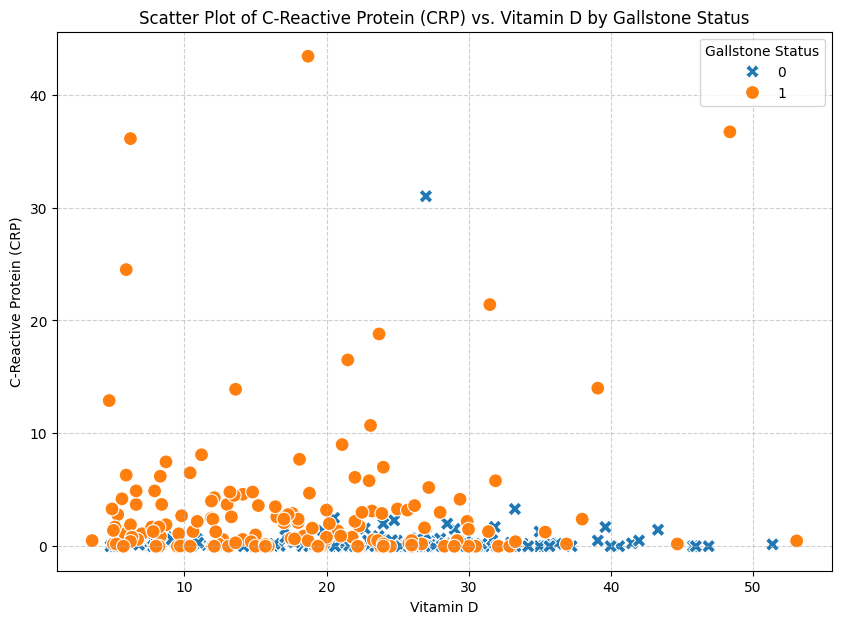

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Vitamin D', y='C-Reactive Protein (CRP)',
                hue='Gallstone Status', style='Gallstone Status',
                markers={0: 'X', 1: 'o'}, # 0 for No Gallstone, 1 for Has Gallstone
                data=df, s=100)
plt.title('Scatter Plot of C-Reactive Protein (CRP) vs. Vitamin D by Gallstone Status')
plt.xlabel('Vitamin D')
plt.ylabel('C-Reactive Protein (CRP)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Discussion

**Question:** Discuss what you learn from the visual?

Based on this visual, I have learned that people with high C-Reactive Protein (CRP) are more likely to have gallstones. On the other hand, Vitman D is negatively correlated with gallstones meaning that people with lower Vitamin D levels are more likely to have gallstones compared to people with high Vitamin D.

### Your Discussion:

# Split the data

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Gallstone Status', axis=1)
y = df['Gallstone Status']

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state for reproducibility
# stratify=y ensures that both training and testing sets have the same proportion of target classes as the input dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nGallstone Status distribution in original dataset:\n", y.value_counts(normalize=True))
print("\nGallstone Status distribution in y_train:\n", y_train.value_counts(normalize=True))
print("\nGallstone Status distribution in y_test:\n", y_test.value_counts(normalize=True))

Shape of X_train: (239, 38)
Shape of X_test: (80, 38)
Shape of y_train: (239,)
Shape of y_test: (80,)

Gallstone Status distribution in original dataset:
 Gallstone Status
0    0.504702
1    0.495298
Name: proportion, dtype: float64

Gallstone Status distribution in y_train:
 Gallstone Status
0    0.506276
1    0.493724
Name: proportion, dtype: float64

Gallstone Status distribution in y_test:
 Gallstone Status
1    0.5
0    0.5
Name: proportion, dtype: float64


# Coding: Train K-Nearest Neighbors (KNN) models for k values 3, 5, 10, 15, and 20;  evaluating and storing both training and testing accuracies for each model

In [ ]:
#Import kNN Classifier. Set the parameter, k=3
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)

#Fit the classifier using the training set
clf.fit(X_train, y_train)

#Check the prediction
print("Test set predictions: {}".format(clf.predict(X_test)))

#Check the traing accuracy and the test accuracy
print("Train set accuracy:{:.5f}". format(clf.score(X_train, y_train)))
print("Test set accuracy: {:.5f}".format(clf.score(X_test, y_test)))

Test set predictions: [1 0 0 1 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 1 1 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 1
 0 1 0 1 0 0 0 0 1 1 1 1 1 0 1 0 0 1 1 1 0 0 1 0 0 1 0 0 1 1 0 1 0 1 0 0 1
 1 1 0 1 1 0]
Train set accuracy:0.74895
Test set accuracy: 0.52500


In [ ]:
#Import kNN Classifier. Set the parameter, k=5
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=5)

#Fit the classifier using the training set
clf.fit(X_train, y_train)

#Check the prediction
print("Test set predictions: {}".format(clf.predict(X_test)))

#Check the traing accuracy and the test accuracy
print("Train set accuracy:{:.5f}". format(clf.score(X_train, y_train)))
print("Test set accuracy: {:.5f}".format(clf.score(X_test, y_test)))

Test set predictions: [1 0 0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0 0 1 1 0 1 0
 0 1 0 1 0 0 1 0 1 1 1 1 1 0 1 0 0 0 1 1 0 0 1 0 0 1 0 0 1 1 1 1 0 0 0 0 1
 0 1 0 1 0 0]
Train set accuracy:0.68619
Test set accuracy: 0.50000


In [ ]:
#Import kNN Classifier. Set the parameter, k=10
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=10)

#Fit the classifier using the training set
clf.fit(X_train, y_train)

#Check the prediction
print("Test set predictions: {}".format(clf.predict(X_test)))

#Check the traing accuracy and the test accuracy
print("Train set accuracy:{:.5f}". format(clf.score(X_train, y_train)))
print("Test set accuracy: {:.5f}".format(clf.score(X_test, y_test)))

Test set predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 1 0 0 0 0 1
 0 0 0 1 0 0]
Train set accuracy:0.65272
Test set accuracy: 0.53750


In [ ]:
#Import kNN Classifier. Set the parameter, k=15
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=15)

#Fit the classifier using the training set
clf.fit(X_train, y_train)

#Check the prediction
print("Test set predictions: {}".format(clf.predict(X_test)))

#Check the traing accuracy and the test accuracy
print("Train set accuracy:{:.5f}". format(clf.score(X_train, y_train)))
print("Test set accuracy: {:.5f}".format(clf.score(X_test, y_test)))

Test set predictions: [1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 0
 1 0 0 1 0 0 1 0 1 0 1 1 0 0 1 1 0 0 0 1 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1
 0 0 0 1 1 0]
Train set accuracy:0.61506
Test set accuracy: 0.46250


In [ ]:
#Import kNN Classifier. Set the parameter, k=20
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=20)

#Fit the classifier using the training set
clf.fit(X_train, y_train)

#Check the prediction
print("Test set predictions: {}".format(clf.predict(X_test)))

#Check the traing accuracy and the test accuracy
print("Train set accuracy:{:.5f}". format(clf.score(X_train, y_train)))
print("Test set accuracy: {:.5f}".format(clf.score(X_test, y_test)))

Test set predictions: [0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 0 1 0 0 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 1 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 1 1
 0 0 0 1 1 0]
Train set accuracy:0.61506
Test set accuracy: 0.45000


# Discussion

* **Question 1:** Comment on the performance of the KNN classifer?

As the k value goes up, the training accuracy goes down and the testing accuracy fluclates at first but drops once k is greater than 10. Both underfitting and overfitting occur depending on the value of k. Smaller k values tend to overfit while larger k values tend to underfit as the model becomes too simple.

* **Question 2:** Which k value is better?
A k value of 10 is the best since it has the smallest gap between the training score and the testing score and it contains the highest testing score out of all the k values.


### Your Discusison:

# Coding: Train a Decision Tree Classifier using the default setting, ensuring no pruning is applied.

In [ ]:
#Importing libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [ ]:

tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

print(f"The maximum depth of the decision tree is: {tree.tree_.max_depth}")
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

The maximum depth of the decision tree is: 10
Accuracy on training set: 1.000
Accuracy on test set: 0.688


# Coding: Train a Decision Tree Classifier using max_depth=4

In [ ]:
# Your Code
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train, y_train)

print(f"The maximum depth of the decision tree is: {tree.tree_.max_depth}")
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

The maximum depth of the decision tree is: 4
Accuracy on training set: 0.862
Accuracy on test set: 0.625


# Coding: Visualize the decision tree, max_depth=4

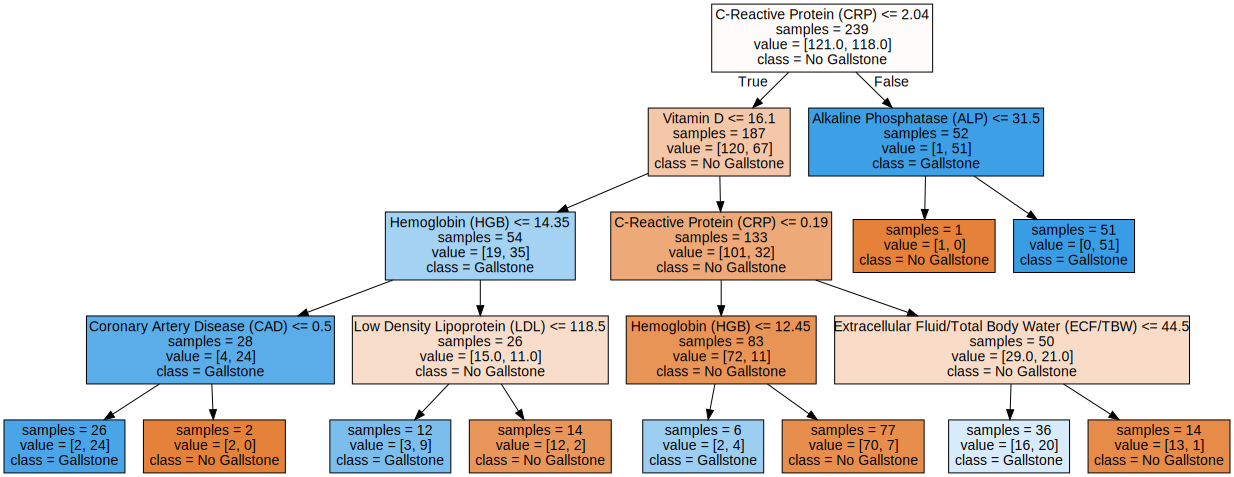

In [ ]:
from sklearn.tree import export_graphviz

export_graphviz(tree, out_file="tree.dot", class_names=["No Gallstone", "Gallstone"],
feature_names=X.columns, impurity=False, filled=True)

import graphviz

with open("tree.dot") as f:
  dot_graph = f.read()
graphviz.Source(dot_graph)

# Coding: Train a Decision Tree Classifier using max_depth=5

In [ ]:
# Your Code:
tree = DecisionTreeClassifier(max_depth=5, random_state=0)
tree.fit(X_train, y_train)

print(f"The maximum depth of the decision tree is: {tree.tree_.max_depth}")
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

The maximum depth of the decision tree is: 5
Accuracy on training set: 0.929
Accuracy on test set: 0.713


# Discussion

* **Question 1:** Comment on the performace of decsion tree classifier.

* **Question 2:** Which decision tree is better?


### Your Discusison:

Question 1:
For the default setting, the training accuracy is 1 and the testing accuracy is 0.688. When the max_depth = 4, the training accuracy is 0.862, and the testing accuracy is 0.625. When the max_depth = 5, the training accuracy goes up to 0.929 and the testing accuracy goes up to 0.713. As we can see, overfitting does occur for all of these scenaros but the gap is the smallest when the max depth is equal to 5.

Question 2:
The decision tree performs better when the max_depth = 5 since the testing accuracy is higher and it has the smallest gap between the training and testing accuracy.

# Coding: Train with Random Forest Model, using default setting



In [ ]:
#Importing the libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [ ]:
#Fitting the model
forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
#Training and testing accuracy on default model
print("Accuracy on training set: {:.3f}".format(forest.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(forest.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.713


# Coding: Train with Random Forest Model, max_depth=5, n_estimators=50

In [ ]:
# Your Code
forest = RandomForestClassifier(max_depth=5, n_estimators=50, random_state=0)
forest.fit(X_train, y_train)

print("Accuracy on training set: {:.3f}".format(forest.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(forest.score(X_test, y_test)))

Accuracy on training set: 0.950
Accuracy on test set: 0.738


# Discussion

* **Question 1:** Comment on the performace of random forest classifier. Both random forest models have high training and testing accuracies. For the default setting, the training accuracy is 1 and the testing accuracy is 0.713. When the max_depth=5 and n_estimators=5, the training score goes down to 0.950 but the testing score increases to 0.738, reducing the gap between the two scores. This means that overfitting is less of an issue.

* **Question 2:** Which random forest is better? The random forest with max_depth=5 and n_estimators=50 is better since the testing accuracy is higher and the gap between the training and testing accuracy is smaller. This means that overfitting is less of an issue.

# Coding: Train Gradient Boosting Model, using default setting



In [ ]:
# Your Code
#Importing the libraries
from sklearn.ensemble import GradientBoostingClassifier

#Fitting the model
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train, y_train)


GradientBoostingClassifier(random_state=0)

In [ ]:
#Training and testing accuracy using the default setting
print("Accuracy on training set: {:.3f}".format(gbrt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gbrt.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.750


# Coding: Train Gradient Boosting Model, learning rate=0.01, n_estimators=150

In [ ]:
#Applying the parameters to our evaulation
gbrt = GradientBoostingClassifier(random_state=0, learning_rate=0.01, n_estimators=150)
gbrt.fit(X_train, y_train)

print("Accuracy on training set: {:.3f}".format(gbrt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gbrt.score(X_test, y_test)))

Accuracy on training set: 0.904
Accuracy on test set: 0.750


# Discussion

* **Question 1:** Comment on the performace of gradient boosting classifier. For the default setting, the training accuracy is 1 and the testing accuracy is 0.750, resutling in overfitting. When the parameters are put in place, the training accuracy goes down to 0.904 and the testing accuracy stays the same.
* **Question 2:** Which gradient boosting tree is better?
The gradient boosting tree with the parameters is better since the gap is smaller between the training and testing score and the testing score stays the same. Since the gap is smaller, overfitting is less of an issue.

### Your Discussion:

# In summery: which model is the best performed model?

### Your Discussion

The best performed model is the gradient boosting tree with the parameters put in place since it has the highest testing accuracy out of all the models and it maintains a small gap between the training and testing accuracies. It still maintains a high training accuracy as well.
